In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import uproot
import pandas as pd
from collections import OrderedDict
from common_utils import *
from visualize import *
from uncertainties import *
from radial_profile import *
import fastjet as fj
import awkward as ak
import time
import pickle
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# Table of Contents

 
1. [Overview](#overview)
2. [General Binning and Plot Labeling](#general-binning-and-plot-labeling)
3. [Load Events from File](#load-events-from-file)
4. [R=0.4 Anti-kt Jets](#r04-anti-kt-jets)
    4.1 [Constructing Jets](#constructing-r04-jets)  
        4.1.1 [Omnifold Anti-kt R=0.4 Jets](#omnifold-anti-kt-r04-jets)  
        4.1.2 [Omnifold Truth Pseudodata Anti-kt R=0.4 Jets](#omnifold-truth-pseudodata-anti-kt-r04-jets)  
    4.2 [Measuring Radial Jet Profile](#measuring-radial-jet-profile)   
        4.2.1 [Compute Radial Profiles](#calculating-average-pt-density-ρ-as-a-function-of-distance-from-jet-axis-r)  
        4.2.2 [Plotting](#plotting-the-results)   
5. [Comparing Algorithms](#comparing-algorithms)  
    5.1 [Constructing Jets](#constructing-jets)   
    5.2 [Measuring Radial Jet Profile](#compute-radial-profiles)    
    5.3 [Plotting Vs On Another](#plotting-vs-on-another)  
    5.4 [Plotting Vs Truth Pseudodata](#plotting-vs-truth-pseudodata)  
6. [R=0.5 Anti-kt Jets](#r05-anti-kt-jets)
7. [Calculating and Measuring Jet Observables](#calculating-and-measuring-jet-observables)  
    7.1 [Build Histograms for a Given Observable](#build-histograms-for-a-given-observable)  
    7.2 [Plotting Results](#plotting-results)
8. [Measuring Total Cross Section vs. Leading Jet Radius](#measuring-total-cross-section-vs-leading-jet-radius)

# Overview

This notebook demonstrates how to use pre-built functions to perform a variety of jet measurements with different clustering parameters and algorithms. Specifically, it covers:

- **Radial profile measurements:** Calculate jet properties as a function of distance from the jet axis.
- **Generalized jet observable measurements:** Define and measure custom jet observables on the fly.
- **Total cross section and jet count:** Measure the total cross section or number of jets as a function of jet radius.

Possible algorithms includs: Cambridge Achan, antikT and kT. Radius parameters are not limited. All events are limited by the Z+jets analysis selections, most notably:

- Tracks must have a minimum $p_T$ of 0.5 GeV and $|\eta| < 2.4$ to be saved.
- Events must contain exactly two muons, with di-lepton pT > 200 GeV
- ... to fill

In order, this notebook will:

  - Define generalized binning and plot labeling 
  - Load events from file
  - build jets
  - measure the radial profile of the built jets
  - calculate and measure jet observables defined inline
  - (slow) perform a total cross section measurements as a function of leading jet radius.



# General Binning and Plot Labeling

In [3]:
ibu_bins = OrderedDict()
ibu_bins["pT_l1"] = np.asarray([25.0, 125.0, 200.0, 300.0, 400.0, 500.0, 800.0])
ibu_bins["pT_l2"] = np.asarray([25.0, 50.0, 75.0, 100.0, 150.0, 200.0, 400.0])
ibu_bins["eta_l1"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["eta_l2"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["phi_l1"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["phi_l2"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["pT_trackj1"] = np.asarray([5.0, 50.0, 100.0, 150.0, 200.0, 300.0, 1000.0])
ibu_bins["pT_trackj2"] = np.asarray([5.0, 25.0, 50.0, 100.0, 500.0])
ibu_bins["y_trackj1"] = np.asarray([-2.5, -2.0, -1.75, -1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5])
ibu_bins["y_trackj2"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
ibu_bins["phi_trackj1"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["phi_trackj2"] = np.asarray([-(np.pi + 1e-5), -2.8, -2.4, -2.0, -1.6, -1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.4, 2.8, (np.pi + 1e-5)])
ibu_bins["pT_ll"] = np.asarray([200.0, 230.0, 300.0, 450.0, 600.0, 1000.0])
ibu_bins["y_ll"] = np.asarray([-2.5, -2.0, -1.5, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5])
ibu_bins["Ntracks_trackj1"] = np.asarray([0.5, 6.5, 10.5, 14.5, 19.5, 25.5, 39.5])
ibu_bins["Ntracks_trackj2"] = np.asarray([0.5, 3.5, 7.5, 11.5, 15.5, 34.5])
ibu_bins["m_trackj1"] = np.asarray([0.0, 8.0, 16.0, 24.0, 32.0, 42.0, 70.0])
ibu_bins["m_trackj2"] = np.asarray([0.0, 5.0, 10.0, 20.0, 40.0] )
ibu_bins["tau1_trackj1"] = np.asarray([0.0, 0.05, 0.1, 0.17, 0.25, 0.35, 0.4, 0.9])
ibu_bins["tau1_trackj2"] = np.asarray([0.0, 0.1, 0.2, 0.35, 0.5, 0.9])
ibu_bins["tau2_trackj1"] = np.asarray([0.0, 0.025, 0.05, 0.08, 0.12, 0.17, 0.25, 0.5])
ibu_bins["tau2_trackj2"] = np.asarray([0.0, 0.025, 0.1, 0.17, 0.25, 0.5])
ibu_bins["tau3_trackj1"] = np.asarray([0.0, 0.025, 0.05, 0.1, 0.3])
ibu_bins["tau3_trackj2"] = np.asarray([0.0, 0.025, 0.08, 0.14, 0.3])
ibu_bins["HT_tracks"] = np.asarray([0.0, 160.0, 235.0, 320.0, 440.0, 700.0, 1700.0])
ibu_bins["Ntracks"] = np.asarray([-0.5, 30.5, 60.5, 85.5, 115.5, 160.5])

#axs[0].set_ylim([0.2,600])

plot_labels = {
    "pT_l1"           : r"Leading lepton $p_{\text{T}}$ [GeV]",
    "pT_l2"           : r"Subleading lepton $p_\text{T}$ [GeV]",
    "eta_l1"          : r"Leading lepton $\eta$",
    "eta_l2"          : r"Subleading lepton $\eta$",
    "phi_l1"          : r"Leading lepton $\phi$",
    "phi_l2"          : r"Subleading lepton $\phi$",
    "pT_trackj1"      : r"Leading jet $p_{\text{T}}$ [GeV]",
    "pT_trackj2"      : r"Subleading jet $p_{\text{T}}$ [GeV]",
    "y_trackj1"       : r"Leading jet $y$",
    "y_trackj2"       : r"Subleading jet $y$",
    "phi_trackj1"     : r"Leading jet $\phi$",
    "phi_trackj2"     : r"Subleading jet $\phi$",
    "pT_ll"           : r"Dilepton $p_{\text{T}}$ [GeV]",
    "y_ll"            : r"Dilepton $y$",
    "Ntracks_trackj1" : r"Leading jet $n_\text{ch}$ ",
    "Ntracks_trackj2" : r"Subleading jet $n_\text{ch}$ ",
    "m_trackj1"       : r"Leading jet $m$ [GeV]",
    "m_trackj2"       : r"Subleading jet $m$ [GeV]",
    "tau1_trackj1"    : r"Leading jet $\tau_1$",
    "tau1_trackj2"    : r"Subleading jet $\tau_1$",
    "tau2_trackj1"    : r"Leading jet $\tau_2$",
    "tau2_trackj2"    : r"Subleading jet $\tau_2$",
    "tau3_trackj1"    : r"Leading jet $\tau_3$",
    "tau3_trackj2"    : r"Subleading jet $\tau_3$",
    "HT_tracks"       : r"$H_T$ [GeV]",
    "Ntracks"         : r"Charged Hadron Multiplicity, $n_\text{ch}$",
    "radial_profile_rho" : r"Distance from jet axis, $r$",
}

labels = {
     'pT_l1' : r'd$\sigma$/d$p_\text{T}^{\mu 1}$ [fb/GeV]',
     'pT_l2' : r'd$\sigma$/d$p_\text{T}^{\mu 2}$ [fb/GeV]',
     'eta_l1' : r'd$\sigma$/d$\eta^{\mu 1}$ [fb]',
     'eta_l2' : r'd$\sigma$/d$\eta^{\mu 2}$ [fb]',
     'phi_l1' : r'd$\sigma$/d$\phi^{\mu 1}$ [fb]',
     'phi_l2' : r'd$\sigma$/d$\phi^{\mu 2}$ [fb]',
     'pT_trackj1' : r'd$\sigma$/d$p_\text{T}$ [fb/GeV]',
     'pT_trackj2' : r'd$\sigma$/d$p_\text{T}$ [fb/GeV]',
     'y_trackj1' : r'd$\sigma$/d$y$ [fb]',
     'y_trackj2' : r'd$\sigma$/d$y$ [fb]',
     'phi_trackj1' : r'd$\sigma$/d$\phi$ [fb]',
     'phi_trackj2' : r'd$\sigma$/d$\phi$ [fb]',
     'pT_ll' : r'd$\sigma$/d$p_\text{T}^{\mu\mu}$ [fb/GeV]',
     'y_ll' : r'd$\sigma$/d$y^{\mu\mu}$ [fb]',
     'Ntracks_trackj1' : r'd$\sigma$/dn$_\text{ch}$ [fb]',
     'Ntracks_trackj2' : r'd$\sigma$/dn$_\text{ch}$ [fb]',
     'm_trackj1' : r'd$\sigma$/d$m$ [fb/GeV]',
     'm_trackj2' : r'd$\sigma$/d$m$ [fb/GeV]',
     'tau1_trackj1' : r'd$\sigma$/d$\tau_1$ [fb]',
     'tau1_trackj2' : r'd$\sigma$/d$\tau_1$ [fb]',
     'tau2_trackj1' : r'd$\sigma$/d$\tau_2$ [fb]',
     'tau2_trackj2' : r'd$\sigma$/d$\tau_2$ [fb]',
     'tau3_trackj1' : r'd$\sigma$/d$\tau_3$ [fb]',
     'tau3_trackj2' : r'd$\sigma$/d$\tau_3$ [fb]',
     'HT_tracks' : r'd$\sigma$/d$H_T$ [fb/GeV]',
     'Ntracks' : r'd$\sigma$/d$n_\text{ch}$ [fb]',
     "radial_profile_rho" : r"Avg. $p_T$ density, $\langle\rho\rangle$ [GeV]",

 }

mapping_mg = {
    "nominal": "weight_mc",
    "weights_theoryQCD": "QCD_dd",
    "weights_theoryPDF": "PDF_MSHT2020",
    "*weights_theoryAlphaS": "w_Alpha_s1",
    "*weights_theoryPSjet": "w_MPIDown",
    "*weights_theoryPSsoft": "w_RenDown",
    "*weights_theoryMPI": "w_Var1Down",
    "*weights_theoryPSscale": "w_Var2Down",
}

mapping_sh = {
    "nominal": "weight_mc",
    "weights_theoryQCD": "QCD_dd",
    "weights_theoryPDF": "PDF_MSHT2020",
    "weights_theoryAlphaS": "Alpha_s1",
    "*weights_theoryPSjet": "w_MPIDown",
    "*weights_theoryPSsoft": "w_RenDown",
    "*weights_theoryMPI": "w_Var1Down",
    "*weights_theoryPSscale": "w_Var2Down",
}

# Load Events from File

In [4]:
# Load all event data from ROOT files

file_path = "/Applications/PhD/Omni_Files/"
#file_path = "/pscratch/sd/m/mbsmith/Omni_Files/"

f_mg = uproot.open(file_path+"ZjetOmnifold_5Jul2025_MGPy8FxFxPlusNonStrong_syst_Test_withdd.root")
t_mg = f_mg["OmniTree"]
truth_pass190 = ak.to_numpy(t_mg["truth_pass190"].array())
truth_pT_ll = ak.to_numpy(t_mg["truth_pT_ll"].array())
truth_pass200 = np.logical_and(truth_pass190, truth_pT_ll > 200)

f_hv = uproot.open(file_path+"ZjetOmnifold_Mar10_Sherpa2211_LookLike_MgFxFx_Test_V5.root")
t_hv = f_hv["OmniTree"]
truth_pass190_hv = ak.to_numpy(t_hv["truth_pass190"].array())
truth_pT_ll_hv   = ak.to_numpy(t_hv["truth_pT_ll"].array())
truth_pass200_hv = np.logical_and(truth_pass190_hv, truth_pT_ll_hv > 200)


ibu_data_jet_obs = file_path+"json_outfiles/IBU_data_pass200andSideBin_jetVars_16Mar26_TestSamples.json"
ibu_data_nom_obs = file_path+"json_outfiles/IBU_data_pass200andSideBin_nomVars_16Mar26_TestSamples.json"
ibu_pd_jet_obs   = file_path+"json_outfiles/IBU_pseudodata_pass200andSideBin_jetVars_16Mar26_TestSamples.json"
ibu_pd_nom_obs   = file_path+"json_outfiles/IBU_pseudodata_pass200andSideBin_nomVars_16Mar26_TestSamples.json"



In [19]:

# Load event weights for pseudodata measurement


# Load event weights for Omnifold data measurement. These get attahed to events in madgraph_events.root
data_weights    = pd.read_hdf( file_path+"data-weights-unshuffled.h5", key="weights", mode="r",)
data_hv_weights = pd.read_hdf( file_path+"data-weights-unshuffled.h5", key="hv_weights", mode="r",)

# # Load all weights from the Omnifold pseudodata measurement.  These get attahed to events in madgraph_events.root
pseudodata_weights      = pd.read_hdf( file_path+"pd-weights-unshuffled.h5", key="weights", mode="r",)
pseudodata_hv_weights   = pd.read_hdf( file_path+"pd-weights-unshuffled.h5", key="hv_weights", mode="r",)
omnifold_weight_file    = pseudodata_weights
omnifold_hv_weight_file = pseudodata_hv_weights


# Create dictionary describing all of the histograms needed for the pseudodata measurement
n_init_weights = [name for name in omnifold_weight_file.keys() if "weights_ensemble_" in name]
dbootstrap_weights = [name for name in omnifold_weight_file.keys() if "weights_bootstrap_data_" in name]
mcbootstrap_weights = [name for name in omnifold_weight_file.keys() if "weights_bootstrap_mc_" in name]
omni_weights = {
    # "prior": madgraph_weights["weights_nominal"][truth_pass200 == 1],
    "nominal": omnifold_weight_file["weights_nominal"].to_numpy()[truth_pass200 == 1],
    **{f"ensemble_{i}": omnifold_weight_file[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(n_init_weights)},
    **{f"bootstrap_data_{i}": omnifold_weight_file[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(dbootstrap_weights)},
    **{f"bootstrap_mc_{i}": omnifold_weight_file[name].to_numpy()[truth_pass200 == 1] for i, name in enumerate(mcbootstrap_weights)},
    "trackEffMain": omnifold_weight_file["weights_trackEffMain"].to_numpy()[truth_pass200 == 1],
    "trackEffJet": omnifold_weight_file["weights_trackEffJet"].to_numpy()[truth_pass200 == 1],
    "trackFake": omnifold_weight_file["weights_trackFake"].to_numpy()[truth_pass200 == 1],
    "trackPtScale": omnifold_weight_file["weights_trackPtScale"].to_numpy()[truth_pass200 == 1],
    "muCalID": omnifold_weight_file["weights_muCalID"].to_numpy()[truth_pass200 == 1],
    "muCalMS": omnifold_weight_file["weights_muCalMS"].to_numpy()[truth_pass200 == 1],
    "muCalResBias": omnifold_weight_file["weights_muCalResBias"].to_numpy()[truth_pass200 == 1],
    # "muCalScale": omnifold_weight_file["weights_muCalScale"].to_numpy()[truth_pass200 == 1],
    "muEffReco": omnifold_weight_file["weights_muEffReco"].to_numpy()[truth_pass200 == 1],
    "muEffIso": omnifold_weight_file["weights_muEffIso"].to_numpy()[truth_pass200 == 1],
    "muEffTrack": omnifold_weight_file["weights_muEffTrack"].to_numpy()[truth_pass200 == 1],
    "muEffTrig": omnifold_weight_file["weights_muEffTrig"].to_numpy()[truth_pass200 == 1],
    "pileup": omnifold_weight_file["weights_pileup"].to_numpy()[truth_pass200 == 1],
    "lumi": omnifold_weight_file["weights_lumi"].to_numpy()[truth_pass200 == 1],
    "dd": omnifold_weight_file["weights_dd"].to_numpy()[truth_pass200 == 1],
    "target_dd": omnifold_weight_file["target_dd"].to_numpy()[truth_pass200 == 1],
    "hvhad": omnifold_weight_file["weights_hvhad"].to_numpy()[truth_pass200 == 1],
    "theoryQCD": omnifold_weight_file["weights_theoryQCD"].to_numpy()[truth_pass200 == 1],
    "theoryPDF": omnifold_weight_file["weights_theoryPDF"].to_numpy()[truth_pass200 == 1],
    "theoryAlphaS": omnifold_weight_file["weights_theoryAlphaS"].to_numpy()[truth_pass200 == 1],
    "theoryPSsoft": omnifold_weight_file["weights_theoryPSsoft"].to_numpy()[truth_pass200 == 1],
    "theoryPSjet": omnifold_weight_file["weights_theoryPSjet"].to_numpy()[truth_pass200 == 1],
    "theoryMPI": omnifold_weight_file["weights_theoryMPI"].to_numpy()[truth_pass200 == 1],
    "theoryPSscale": omnifold_weight_file["weights_theoryPSscale"].to_numpy()[truth_pass200 == 1],
    "topBackground": omnifold_weight_file["weights_topBackground"].to_numpy()[truth_pass200 == 1],
    "nonstrongDiboson": omnifold_weight_file["weights_nonstrongDiboson"].to_numpy()[truth_pass200 == 1],
    "nonstrongEW": omnifold_weight_file["weights_nonstrongEW"].to_numpy()[truth_pass200 == 1],
}


hv_weights = {  "nominal": omnifold_hv_weight_file["weights_hv"].to_numpy()[truth_pass200_hv == 1]}


truth_pd_path = file_path+"TruthPseudodata_Sherpa2211DY_Dibo_EW_PowhegPythiaTop_PosWeights_WithTracks_June2025_Fixed.root"
f_pd = uproot.open(truth_pd_path)
t_pd = f_pd["OmniTree"]
truth_pass190_pd = ak.to_numpy(t_pd["truth_pass190"].array())
truth_pT_ll_pd   = ak.to_numpy(t_pd["truth_pT_ll"].array())
truth_pass200_pd = np.logical_and(truth_pass190_pd, truth_pT_ll_pd > 200)
pd_truth_weights = { "nominal": ak.to_numpy(t_pd["weight_mc"].array())[truth_pass200_pd == 1]}


Load tracks

In [6]:
if isinstance(t_mg, list):
    all_kinematics_omni = [ get_hadron_kinematics( t, get_truth=True, selection=sel,) for t, sel in zip(t_mg, truth_pass200)]
    pt_omni             = ak.concatenate([k[0] for k in all_kinematics_omni], axis=0)
    eta_omni            = ak.concatenate([k[1] for k in all_kinematics_omni], axis=0)
    phi_omni            = ak.concatenate([k[2] for k in all_kinematics_omni], axis=0)
    masses_omni         = ak.concatenate([k[3] for k in all_kinematics_omni], axis=0)
else:
    pt_omni, eta_omni, phi_omni, masses_omni = get_hadron_kinematics(t_mg, get_truth=True, selection = truth_pass200)
    
if isinstance(t_hv, list):
    all_kinematics_omni = [ get_hadron_kinematics( t, get_truth=True, selection=sel,) for t, sel in zip(t_hv, truth_pass200_hv)]
    pt_hv             = ak.concatenate([k[0] for k in all_kinematics_omni], axis=0)
    eta_hv            = ak.concatenate([k[1] for k in all_kinematics_omni], axis=0)
    phi_hv            = ak.concatenate([k[2] for k in all_kinematics_omni], axis=0)
    masses_hv         = ak.concatenate([k[3] for k in all_kinematics_omni], axis=0)
else:
    pt_hv, eta_hv, phi_hv, masses_hv = get_hadron_kinematics(t_hv, get_truth=True, selection = truth_pass200_hv)


if isinstance(t_pd, list):        
    all_kinematics          = [ get_hadron_kinematics( t, get_truth=True, selection=sel,) for t, sel in zip(t_pd, truth_pass200_pd)]
    pt_pd_truth             = ak.concatenate([k[0] for k in all_kinematics], axis=0)
    eta_pd_truth            = ak.concatenate([k[1] for k in all_kinematics], axis=0)
    phi_pd_truth            = ak.concatenate([k[2] for k in all_kinematics], axis=0)
    masses_pd_truth         = ak.concatenate([k[3] for k in all_kinematics], axis=0)
else:
    pt_pd_truth, eta_pd_truth, phi_pd_truth, masses_pd_truth = get_hadron_kinematics(t_pd, get_truth=True, selection = truth_pass200_pd)

## Constructing R=0.4 Jets
### Omnifold Anti-kt R=0.4 Jets

In [10]:

algorithm = fj.antikt_algorithm
R = 0.4
n_jobs = 4
jets_omni, event_jet_indices_omni = build_jets(
    algorithm=algorithm,
    R=R,
    pt=pt_omni,
    eta=eta_omni,
    phi=phi_omni,
    masses=masses_omni,
    n_jobs=n_jobs,
)

jets_hv, event_jet_indices_hv = build_jets(
    algorithm = algorithm,
    R      = R,
    pt     = pt_hv,
    eta    = eta_hv,
    phi    = phi_hv,
    masses = masses_hv,
    n_jobs = n_jobs,
)

Preparing 1036809 events for clustering
Processing 1036809 events with 4 jobs


Clustering events:   0%|          | 315/1036809 [00:00<05:32, 3120.73event/s]

#--------------------------------------------------------------------------
#--------------------------------------------------------------------------
#                         FastJet release #                         FastJet release 3.5.13.5.1

#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#---------------------

Clustering events: 100%|██████████| 1036809/1036809 [03:49<00:00, 4524.31event/s]


### Omnifold Truth Pseudodata Anti-kt R=0.4 Jets

In [8]:
if not load_jets_from_file:
    jets_pd_truth, event_jet_indices_pd_truth = build_jets(
        algorithm=algorithm,
        R=R,
        pt=pt_pd_truth,
        eta=eta_pd_truth,
        phi=phi_pd_truth,
        masses=masses_pd_truth,
        n_jobs=n_jobs,
    )


Preparing 9741735 events for clustering
Processing 9741735 events with 8 jobs


Clustering events:   0%|          | 953/9741735 [00:00<1:06:17, 2449.27event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

Clustering events: 100%|██████████| 9741735/9741735 [20:35<00:00, 7884.66event/s]  


In [9]:
save_jets_to_file = True
if (save_jets_to_file):
    ak.to_parquet(jets_omni,                  file_path +"output/jets_omni_pd.parquet")
    ak.to_parquet(event_jet_indices_omni,     file_path +"output/event_jet_indices_omni_pd.parquet")
    ak.to_parquet(jets_hv,                    file_path +"output/jets_hv_pd.parquet")
    ak.to_parquet(event_jet_indices_hv,       file_path +"output/event_jet_indices_hv_pd.parquet")
    ak.to_parquet(jets_pd_truth,              file_path +"output/jets_pd_truth.parquet")
    ak.to_parquet(event_jet_indices_pd_truth, file_path +"output/event_jet_indices_pd_truth.parquet")

In [9]:
load_jets_from_file = True
if (load_jets_from_file):
    jets_omni                  = ak.from_parquet(file_path +"output/jets_omni_pd.parquet")
    event_jet_indices_omni     = ak.from_parquet(file_path +"output/event_jet_indices_omni_pd.parquet")
    jets_hv                    = ak.from_parquet(file_path +"output/jets_hv_pd.parquet")
    event_jet_indices_hv       = ak.from_parquet(file_path +"output/event_jet_indices_hv_pd.parquet")
    jets_pd_truth              = ak.from_parquet(file_path +"output/jets_pd_truth.parquet")
    event_jet_indices_pd_truth = ak.from_parquet(file_path +"output/event_jet_indices_pd_truth.parquet")


ValueError: no *.parquet or *.parq matches for path '/Applications/PhD/Omni_Files/output/jets_omni_pd.parquet'

### Measuring Radial Jet Profile
#### Calculating average $p_T$ density, $\langle\rho\rangle$ [GeV] as a function of distance from jet axis, r
Calculates the per jet average $p_T$ of the 4 vector sum of all tracks contained within an annulus of inner radius $r-\Delta r$ (lower bin edge, inclusive) and $r+\Delta r$ (upper bin edge,exclusve), where r is given by the center value of the binning defined by the list r_edges.

In [20]:
r_edges  = np.array([0,0.025,0.05,0.075,0.1,0.125,0.15,0.175,0.2,0.225,0.25,0.275,0.3,0.325,0.35,0.355,0.36,0.365,0.37,0.375,0.380,0.385,0.39,0.395,0.4,0.405,0.41,0.415,0.42,0.425,0.45,0.475,0.5,0.525,0.55,0.575,0.6])
r_edges  = np.concatenate([np.linspace(0, 0.4, 11),
    [0.475, 0.55, 0.625]])
save_hists = True
load_hists = False

if not load_hists:
    radial_prof_omni      = jet_radial_profile_parallel(
        jets              = jets_omni,
        event_jet_indices = event_jet_indices_omni,
        track_pt          = pt_omni, track_eta=eta_omni, track_phi=phi_omni, track_mass=masses_omni,
        annulus_edges     = r_edges,
        weights_dict      = omni_weights,
        only_associated   = False,
        jet_pt_range      = np.array([120,150]),
        jet_y_max         = 1,
        use_rho_old       = False,
        compute_psi       = False,
        only_leading_jet  = False,
        max_events        = -1,
        n_jobs            = n_jobs,
    )
    print("Omni radial profile computed\n")
    radial_prof_hv        = jet_radial_profile_parallel(
        jets              = jets_hv,
        event_jet_indices = event_jet_indices_hv,
        track_pt          = pt_hv, track_eta=eta_hv, track_phi=phi_hv, track_mass=masses_hv,
        annulus_edges     = r_edges,
        weights_dict      = hv_weights,
        only_associated   = False,
        jet_pt_range      = np.array([120,150]),
        jet_y_max         = 1,
        use_rho_old       = False,
        compute_psi       = False,
        only_leading_jet  = False,
        max_events        = -1,
        n_jobs            = n_jobs,
    )
    print("Omni hv radial profile computed\n")

    # this just takes the outputs from the hv run, and stores it as a variation on nom in the Omni result, so it can be treated as a syst error later.
    for obs, weights in radial_prof_hv.items():
    if "nominal" in obs:
        radial_prof_omni["hv"] = weights  

    radial_prof_pd_truth  = jet_radial_profile_parallel(
        jets              = jets_pd_truth,
        event_jet_indices = event_jet_indices_pd_truth,
        track_pt          = pt_pd_truth, track_eta=eta_pd_truth, track_phi=phi_pd_truth, track_mass=masses_pd_truth,
        annulus_edges     = r_edges,
        weights_dict      = pd_truth_weights,
        only_associated   = False,
        jet_pt_range      = np.array([120,150]),
        jet_y_max         = 1,
        use_rho_old       = False,
        compute_psi       = False,
        only_leading_jet  = False,
        max_events        = -1,
        n_jobs            = n_jobs,
    )
    print("truth pd radial profile computed")

0% complete
10% complete (103681/1036809 events)
20% complete (207362/1036809 events)
30% complete (311043/1036809 events)
40% complete (414724/1036809 events)
50% complete (518405/1036809 events)
60% complete (622086/1036809 events)
70% complete (725767/1036809 events)
80% complete (829448/1036809 events)
89% complete (933129/1036809 events)
99% complete (1036809/1036809 events)


#### Plotting the results

In [8]:
save_hists = False
load_hists = True
if save_hists:
    with open(file_path+"output/radial_profile_omni_pd.pkl", "wb") as f:
        pickle.dump(radial_prof_omni, f)
    with open(file_path+"output/radial_profile_pd_truth.pkl", "wb") as f:
        pickle.dump(radial_prof_pd_truth, f)

if load_hists:
    with open(os.path.join(file_path+"output/radial_profile_omni_pd.pkl"), "rb") as f:
        radial_prof_omni = pickle.load(f)
    with open(os.path.join(file_path+"output/radial_profile_pd_truth.pkl"), "rb") as f:
        radial_prof_pd_truth = pickle.load(f)

Chi-squared test: dof=12, χ²=22.26521, p-value=0.0347


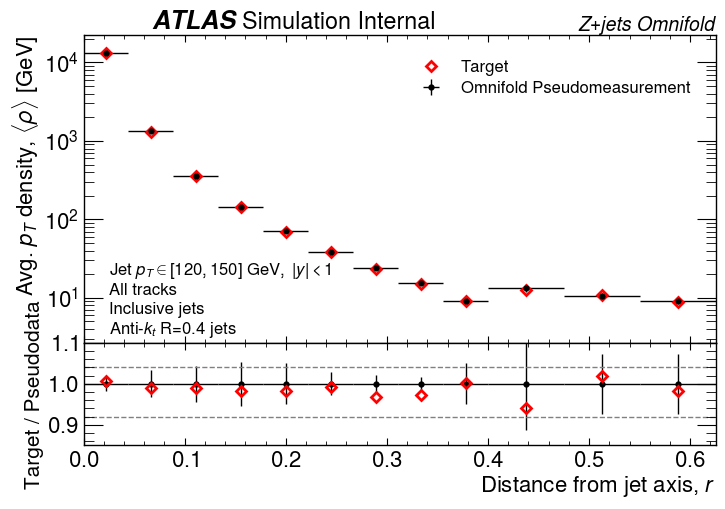

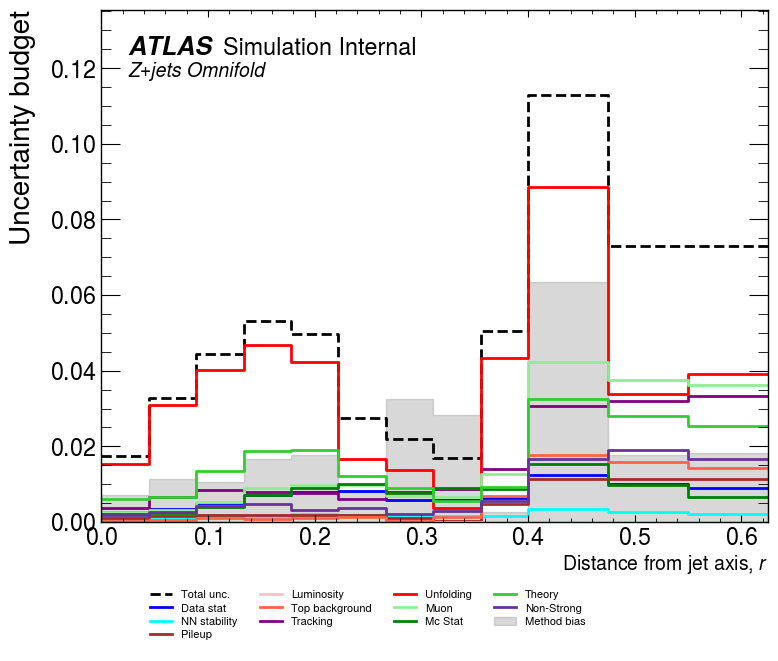

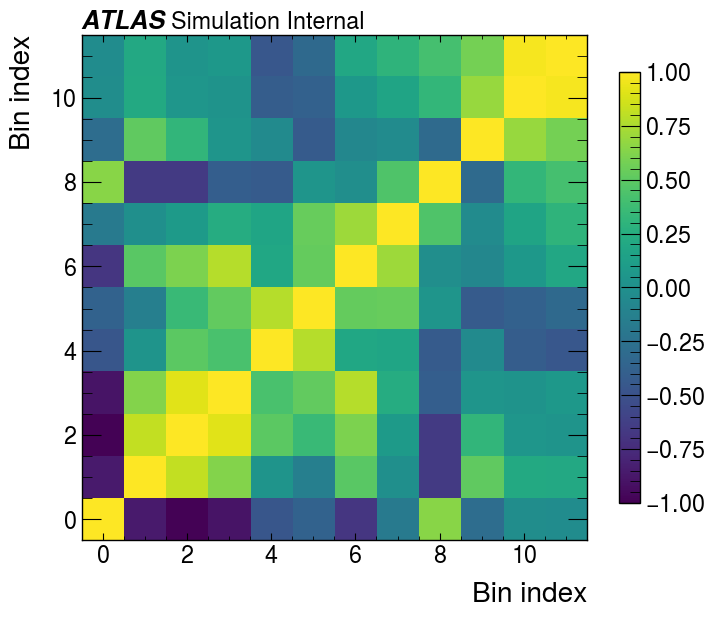

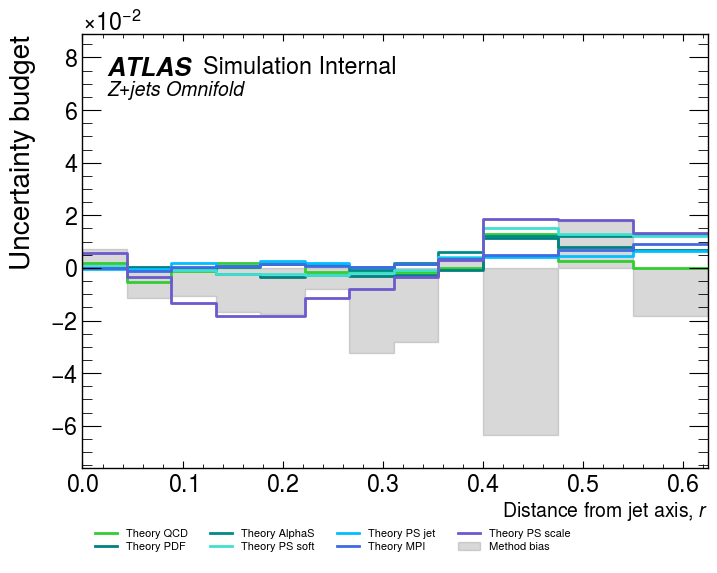

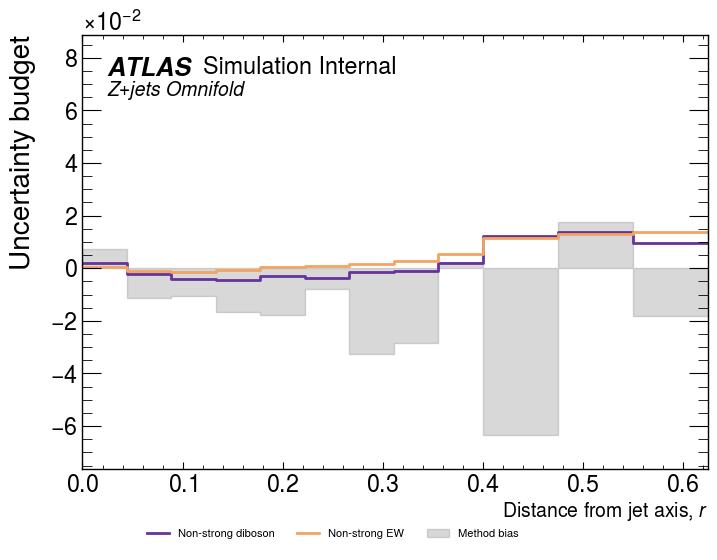

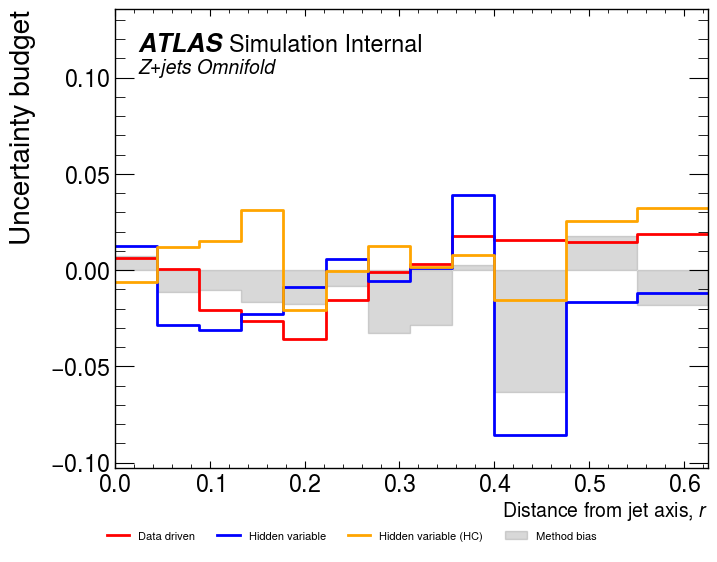

In [18]:
r_edges  = np.concatenate([np.linspace(0, 0.4, 10),
    [0.475, 0.55, 0.625]])
textbox = {
    "left_align": 0.04,
    "top_align": 0.27,
    # "text": "Jet $p_{T} \\in [120,150]~\\text{GeV},~ |y| < 1$\nAll tracks\nInclusive jets\nAnti-$k_t$ R=0.4 jets",
    "text": "Jet $p_{T} \\in [120,150]~\\text{GeV},~ |y| < 1$\nAll tracks\nInclusive jets\nAnti-$k_t$ R=0.4 jets",
    "fontsize": 12
}
formating_PD = {
    "is_madgraph": False,
    "is_omni_data": False,
    "is_truth_pd": True,
    "color": "red",
    "marker": "D",
    "label": "Target",
}


pdf_name = "plots/pd/radial_profile_rho.pdf"
draw_plot(
    omni_results = radial_prof_omni,
    results_list    = [radial_prof_pd_truth],
    formatting_dicts = [formating_PD],
    binning = r_edges,
    ylabel = labels["radial_profile_rho"],
    xlabel = plot_labels["radial_profile_rho"],
    draw_uncertainty_budget = True,
    is_xSec = False,
    is_omni_data=False,
    ratio_ylim  = [0.65,1.35],
    text_box = textbox,
    pdf_name = pdf_name,
    is_profile = True,
    smooth_hv = False
)    

# draw_uncertainty_group(
#     omni_results = radial_prof_omni,
#     binning = r_edges,
#     xlabel = plot_labels["radial_profile_rho"],
#     group = "Theory",
#     signed = True,
#     target_hist = radial_prof_pd_truth
# )

# draw_uncertainty_group(
#     omni_results = radial_prof_omni,
#     binning = r_edges,
#     xlabel = plot_labels["radial_profile_rho"],
#     group = "Non-strong",
#     signed = True,
#     target_hist = radial_prof_pd_truth
# )
# draw_uncertainty_group(
#     omni_results = radial_prof_omni,
#     binning = r_edges,
#     xlabel = plot_labels["radial_profile_rho"],
#     group = "Unfolding",
#     signed = True,
#     smooth_hv = False,
#     target_hist = radial_prof_pd_truth
# )


## Comparing Algorithms
### Constructing Jets

In [19]:
R = 0.4
n_jobs = 4

algorithm = fj.kt_algorithm
jets_omni_kt, event_jet_indices_omni_kt = build_jets(
    algorithm=algorithm,
    R=R,
    pt=pt_omni,
    eta=eta_omni,
    phi=phi_omni,
    masses=masses_omni,
    n_jobs=n_jobs,
)

algorithm = fj.cambridge_algorithm
jets_omni_CA, event_jet_indices_omni_CA = build_jets(
    algorithm=algorithm,
    R=R,
    pt=pt_omni,
    eta=eta_omni,
    phi=phi_omni,
    masses=masses_omni,
    n_jobs=n_jobs,
)

algorithm = fj.kt_algorithm
jets_hv_kt, event_jet_indices_hv_kt = build_jets(
    algorithm=algorithm,
    R=R,
    pt=pt_hv,
    eta=eta_hv,
    phi=phi_hv,
    masses=masses_hv,
    n_jobs=n_jobs,
)

algorithm = fj.cambridge_algorithm
jets_hv_CA, event_jet_indices_hv_CA = build_jets(
    algorithm=algorithm,
    R=R,
    pt=pt_hv,
    eta=eta_hv,
    phi=phi_hv,
    masses=masses_hv,
    n_jobs=n_jobs,
)


algorithm = fj.kt_algorithm
jets_pd_truth_kt, event_jet_indices_pd_truth_kt = build_jets(
    algorithm=algorithm,
    R=R,
    pt=pt_pd_truth,
    eta=eta_pd_truth,
    phi=phi_pd_truth,
    masses=masses_pd_truth,
    n_jobs=n_jobs,
)

algorithm = fj.cambridge_algorithm
jets_pd_truth_CA, event_jet_indices_pd_truth_CA = build_jets(
    algorithm=algorithm,
    R=R,
    pt=pt_pd_truth,
    eta=eta_pd_truth,
    phi=phi_pd_truth,
    masses=masses_pd_truth,
    n_jobs=n_jobs,
)


Preparing 1036809 events for clustering
Processing 1036809 events with 4 jobs


Clustering events:   0%|          | 427/1036809 [00:01<34:36, 499.01event/s] 

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

Clustering events: 100%|██████████| 1036809/1036809 [03:57<00:00, 4373.51event/s]


Preparing 1036809 events for clustering
Processing 1036809 events with 4 jobs


...

Clustering events: 100%|██████████| 1377524/1377524 [05:16<00:00, 4348.87event/s]


Preparing 1377524 events for clustering
Processing 1377524 events with 4 jobs


Clustering events:   0%|          | 295/1377524 [00:00<47:16, 485.60event/s] 

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

Clustering events: 100%|██████████| 1377524/1377524 [05:18<00:00, 4325.98event/s]


In [9]:
save_jets = False
if save_jets:
    ak.to_parquet(jets_omni_kt,                file_path +"output/jets_omni_pd_kt.parquet")
    ak.to_parquet(event_jet_indices_omni_kt,   file_path +"output/event_jet_indices_omni_pd_kt.parquet")
    ak.to_parquet(jets_omni_CA,                file_path +"output/jets_omni_pd_CA.parquet")
    ak.to_parquet(event_jet_indices_omni_CA,   file_path +"output/event_jet_indices_omni_pd_CA.parquet")
    ak.to_parquet(jets_hv_kt,                  file_path +"output/jets_hv_pd_kt.parquet")
    ak.to_parquet(event_jet_indices_hv_kt,     file_path +"output/event_jet_indices_hv_pd_kt.parquet")
    ak.to_parquet(jets_hv_CA,                  file_path +"output/jets_hv_pd_CA.parquet")
    ak.to_parquet(event_jet_indices_hv_CA,     file_path +"output/event_jet_indices_hv_pd_CA.parquet")

    ak.to_parquet(jets_pd_truth_kt,                  file_path +"output/jets_pd_truth_kt.parquet")
    ak.to_parquet(event_jet_indices_pd_truth_kt,     file_path +"output/event_jet_indices_pd_truth_kt.parquet")
    ak.to_parquet(jets_pd_truth_CA,                 file_path +"output/jets_pd_truth_CA.parquet")
    ak.to_parquet(event_jet_indices_pd_truth_CA,     file_path +"output/event_jet_indices_pd_truth_CA.parquet")

load_jets = True
if load_jets:
    jets_omni_kt              = ak.from_parquet(file_path +"output/jets_omni_pd_kt.parquet")
    event_jet_indices_omni_kt = ak.from_parquet(file_path +"output/event_jet_indices_omni_pd_kt.parquet")
    jets_omni_CA              = ak.from_parquet(file_path +"output/jets_omni_pd_CA.parquet") 
    event_jet_indices_omni_CA = ak.from_parquet(file_path +"output/event_jet_indices_omni_pd_CA.parquet")
    jets_hv_kt                = ak.from_parquet(file_path +"output/jets_hv_pd_kt.parquet")
    event_jet_indices_hv_kt   = ak.from_parquet(file_path +"output/event_jet_indices_hv_pd_kt.parquet")
    jets_hv_CA                = ak.from_parquet(file_path +"output/jets_hv_pd_CA.parquet")
    event_jet_indices_hv_CA   = ak.from_parquet(file_path +"output/event_jet_indices_hv_pd_CA.parquet")

    jets_pd_truth_kt              = ak.from_parquet(file_path +"output/jets_pd_truth_kt.parquet")
    event_jet_indices_pd_truth_kt = ak.from_parquet(file_path +"output/event_jet_indices_pd_truth_kt.parquet")
    jets_pd_truth_CA              = ak.from_parquet(file_path +"output/jets_pd_truth_CA.parquet")
    event_jet_indices_pd_truth_CA = ak.from_parquet(file_path +"output/event_jet_indices_pd_truth_CA.parquet")


### Compute Radial Profiles

In [13]:
r_edges  = np.concatenate([np.linspace(0, 0.4, 10),
    [0.475, 0.55, 0.625]])
radial_prof_kt        = jet_radial_profile_parallel(
    jets              = jets_omni_kt,
    event_jet_indices = event_jet_indices_omni_kt,
    track_pt          = pt_omni, track_eta=eta_omni, track_phi=phi_omni, track_mass=masses_omni,
    annulus_edges     = r_edges,
    weights_dict      = omni_weights,
    only_associated   = False,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)
print("kt radial profile computed")
radial_prof_CA        = jet_radial_profile_parallel(
    jets              = jets_omni_CA,
    event_jet_indices = event_jet_indices_omni_CA,
    track_pt          = pt_omni, track_eta=eta_omni, track_phi=phi_omni, track_mass=masses_omni,
    annulus_edges     = r_edges,
    weights_dict      = omni_weights,
    only_associated   = False,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)
print("CA radial profile computed")
radial_prof_hv_kt     = jet_radial_profile_parallel(
    jets              = jets_hv_kt,
    event_jet_indices = event_jet_indices_hv_kt,
    track_pt          = pt_hv, track_eta=eta_hv, track_phi=phi_hv, track_mass=masses_hv,
    annulus_edges     = r_edges,
    weights_dict      = hv_weights,
    only_associated   = False,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)
print("HV kt radial profile computed")
radial_prof_hv_CA     = jet_radial_profile_parallel(
    jets              = jets_hv_CA,
    event_jet_indices = event_jet_indices_hv_CA,
    track_pt          = pt_hv, track_eta=eta_hv, track_phi=phi_hv, track_mass=masses_hv,
    annulus_edges     = r_edges,
    weights_dict      = hv_weights,
    only_associated   = False,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)

for obs, weights in radial_prof_hv_kt.items():
    if "nominal" in obs:
        radial_prof_kt["hv"] = weights
for obs, weights in radial_prof_hv_CA.items():
    if "nominal" in obs:
        radial_prof_CA["hv"] = weights


radial_prof_kt_pd_truth = jet_radial_profile_parallel(
    jets              = jets_pd_truth_kt,
    event_jet_indices = event_jet_indices_pd_truth_kt,
    track_pt          = pt_pd_truth, track_eta=eta_pd_truth, track_phi=phi_pd_truth, track_mass=masses_pd_truth,
    annulus_edges     = r_edges,
    weights_dict      = pd_truth_weights,
    only_associated   = False,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)

print("kt radial profile computed")
radial_prof_CA_pd_truth  = jet_radial_profile_parallel(
    jets              = jets_pd_truth_CA,
    event_jet_indices = event_jet_indices_pd_truth_CA,
    track_pt          = pt_pd_truth, track_eta=eta_pd_truth, track_phi=phi_pd_truth, track_mass=masses_pd_truth,
    annulus_edges     = r_edges,
    weights_dict      = pd_truth_weights,
    only_associated   = False,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)


0% complete
10% complete (103681/1036809 events)
20% complete (207362/1036809 events)
30% complete (311043/1036809 events)
40% complete (414724/1036809 events)
50% complete (518405/1036809 events)
60% complete (622086/1036809 events)
70% complete (725767/1036809 events)
80% complete (829448/1036809 events)
89% complete (933129/1036809 events)
99% complete (1036809/1036809 events)
kt radial profile computed
0% complete
10% complete (103681/1036809 events)
20% complete (207362/1036809 events)
30% complete (311043/1036809 events)
40% complete (414724/1036809 events)
50% complete (518405/1036809 events)
60% complete (622086/1036809 events)
70% complete (725767/1036809 events)
80% complete (829448/1036809 events)
89% complete (933129/1036809 events)
99% complete (1036809/1036809 events)
CA radial profile computed
0% complete
10% complete (137753/1377524 events)
20% complete (275505/1377524 events)
30% complete (413258/1377524 events)
40% complete (551010/1377524 events)
50% complete (688762

In [10]:
save_hists = False
if save_hists:
    with open(file_path+"output/radial_profile_kt_pd.pkl", "wb") as f:
        pickle.dump(radial_prof_kt, f)
    with open(file_path+"output/radial_profile_CA_pd.pkl", "wb") as f:
        pickle.dump(radial_prof_CA, f)
    with open(file_path+"output/radial_profile_kt_pd_truth.pkl", "wb") as f:
        pickle.dump(radial_prof_kt_pd_truth, f)
    with open(file_path+"output/radial_profile_CA_pd_truth.pkl", "wb") as f:
        pickle.dump(radial_prof_CA_pd_truth, f)
        
load_hists = True
if load_hists:
    with open(file_path+"output/radial_profile_kt_pd.pkl", "rb") as f:
        radial_prof_kt = pickle.load(f)
    with open(file_path+"output/radial_profile_CA_pd.pkl", "rb") as f:
        radial_prof_CA = pickle.load(f)
    with open(file_path+"output/radial_profile_kt_pd_truth.pkl", "rb") as f:
        radial_prof_kt_pd_truth = pickle.load(f)
    with open(file_path+"output/radial_profile_CA_pd_truth.pkl", "rb") as f:
        radial_prof_CA_pd_truth = pickle.load(f)
    # with open(os.path.join(file_path+"output/radial_profile_omni_pd.pkl"), "rb") as f:
    #     radial_prof_omni = pickle.load(f)
    # with open(os.path.join(file_path+"output/radial_profile_pd_truth.pkl"), "rb") as f:
    #     radial_prof_pd_truth = pickle.load(f)

### Plotting Vs On Another

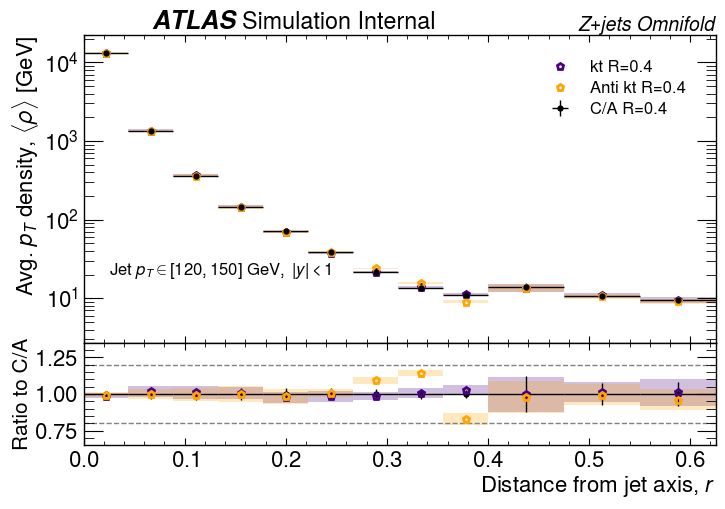

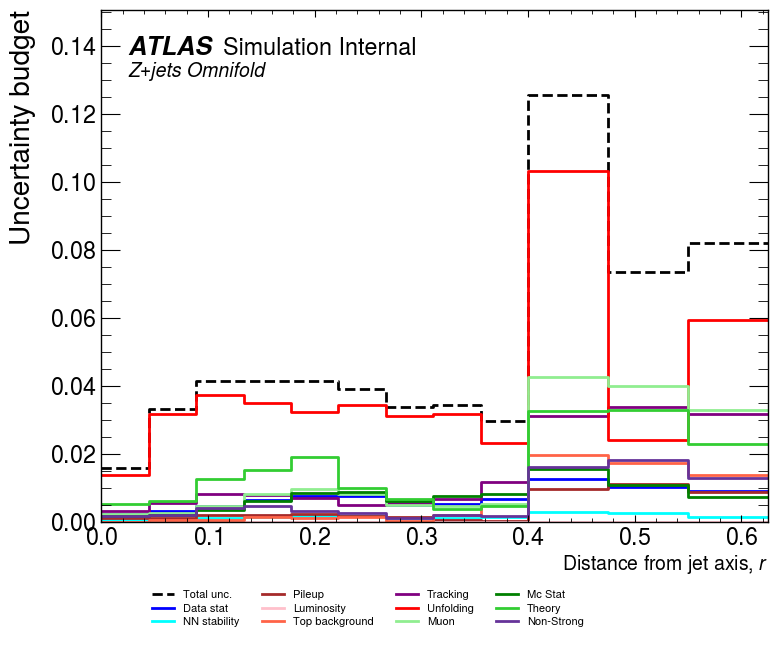

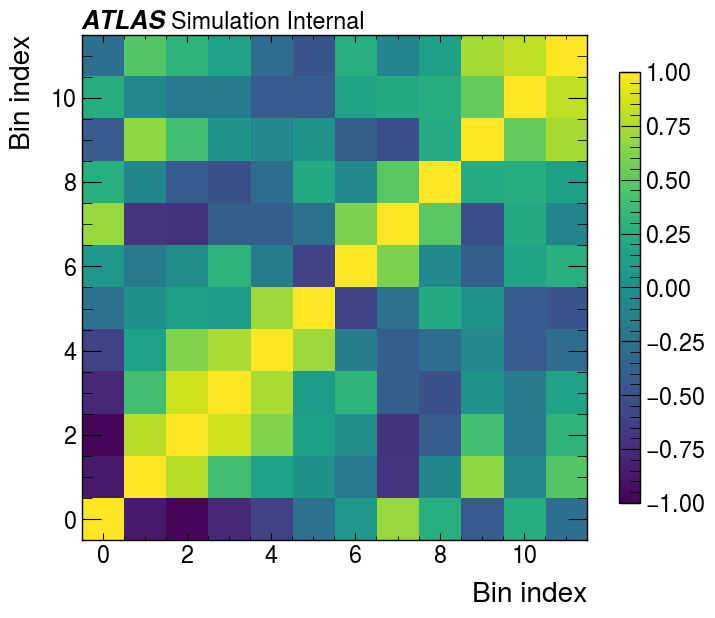

In [16]:
formating_CA = {
    "is_madgraph": False,
    "is_omni_data": True,
    "is_truth_pd" : False,
    "color": "seagreen",
    "marker": "D",
    "label": "Cambridge-Aachen R=0.4 ",
}
formating_kt = {
    "is_madgraph": False,
    "is_omni_data": True,
    "is_truth_pd" : False,
    "color": "indigo",
    "marker": "p",
    "label": "kt R=0.4 ",
}

formating_Anit_kt = {
    "is_madgraph": False,
    "is_omni_data": True,
    "is_truth_pd" : False,
    "color": "orange",
    "marker": "p",
    "label": "Anti kt R=0.4 ",
}


# results_list    = [radial_prof_CA, radial_prof_kt]
# formatting_dicts = [formating_CA, formating_kt]

results_list     = [radial_prof_kt, radial_prof_omni]
formatting_dicts = [formating_kt, formating_Anit_kt]

textbox2 = {
    "left_align": 0.04,
    "top_align": 0.27,
    "text": "Jet $p_{T} \\in [120,150]~\\text{GeV},~ |y| < 1$",
    "fontsize": 12
}

pdf_name = "plots/pd/radial_rho_JetAlgos.pdf"

draw_plot(
    omni_results    = radial_prof_CA,
    binning         = r_edges,
    ylabel          = labels["radial_profile_rho"],
    xlabel          = plot_labels["radial_profile_rho"],
    yratiolabel     = "Ratio to C/A",
    draw_uncertainty_budget = True,
    is_xSec         = False,
    ratio_ylim      = [0.65,1.35],
    text_box        = textbox2,
    results_list    = results_list,
    formatting_dicts = formatting_dicts,
    omni_label      = "C/A R=0.4",
    pdf_name        = pdf_name,
    smooth_hv       = False
) 

### Plotting Vs Truth Pseudodata

Chi-squared test: dof=12, χ²=22.26521, p-value=0.0347
Chi-squared test: dof=12, χ²=33.80496, p-value=0.0007
Chi-squared test: dof=12, χ²=31.11359, p-value=0.0019


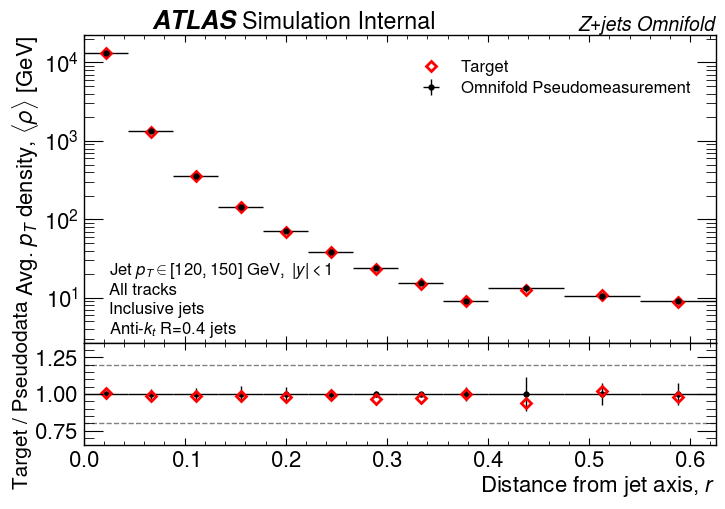

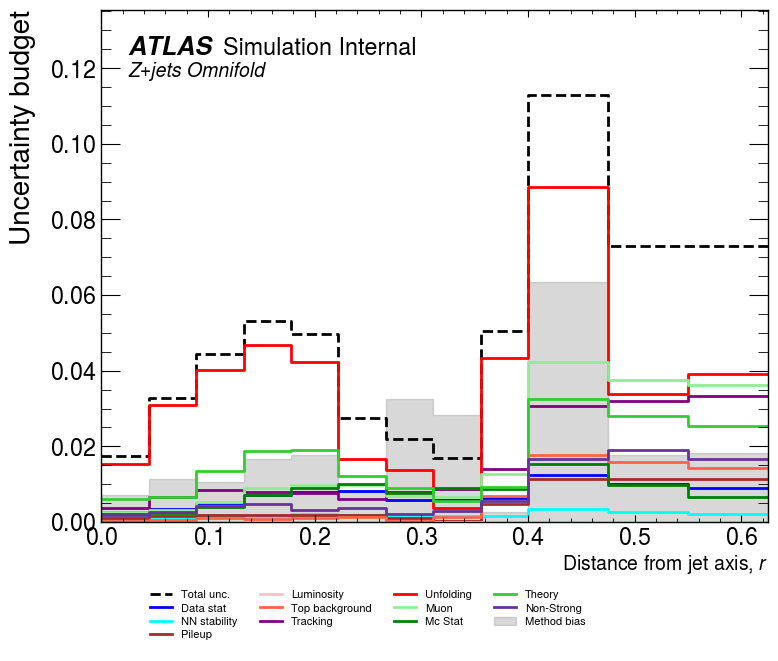

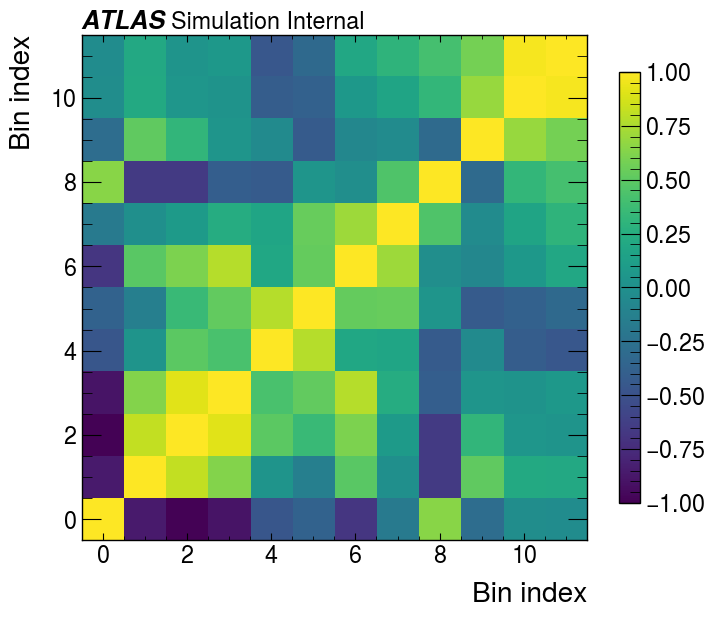

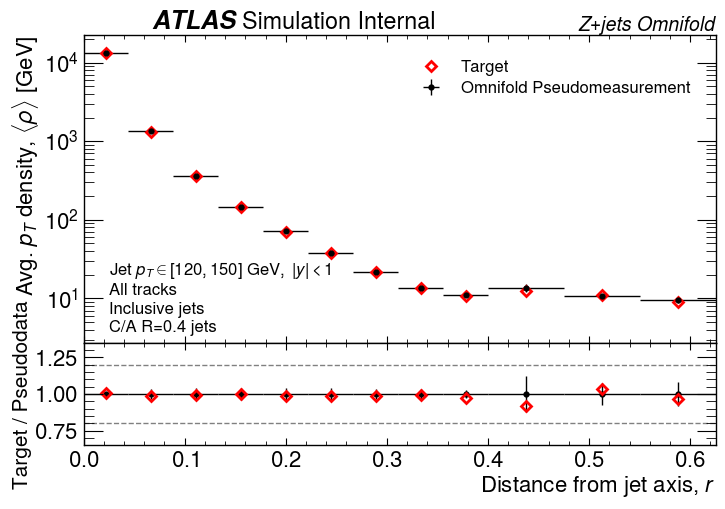

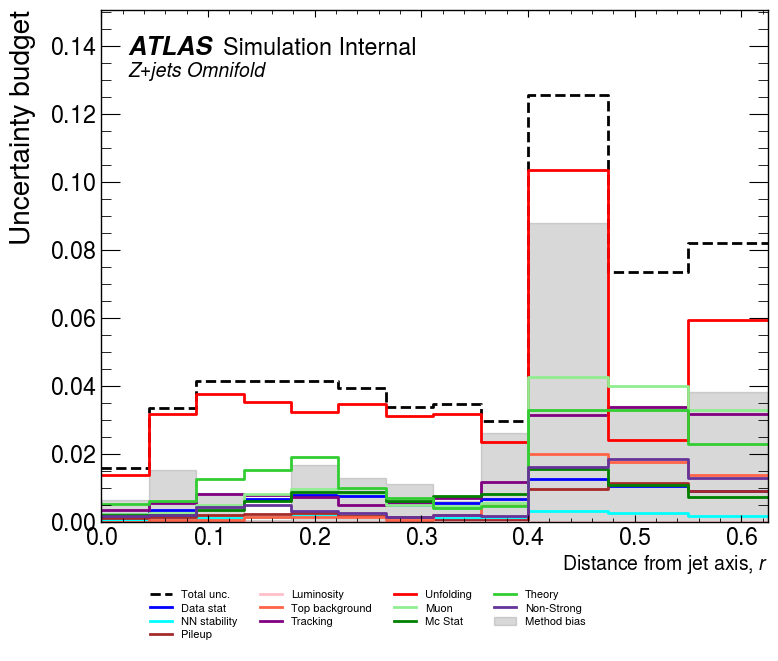

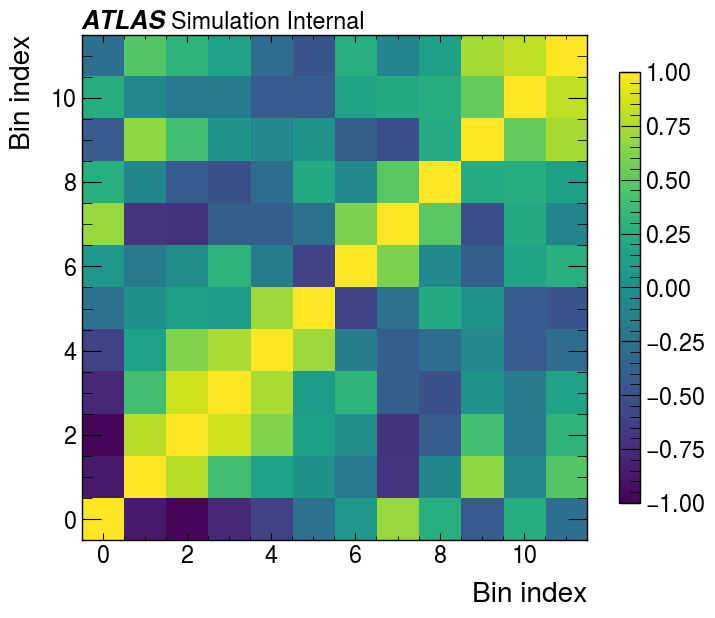

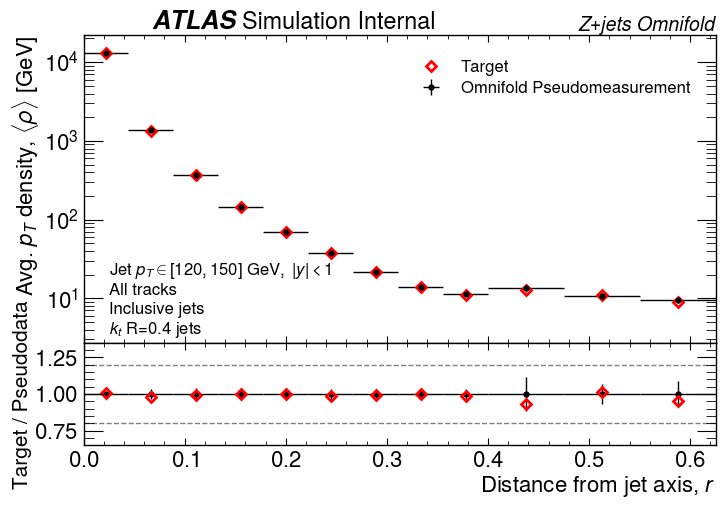

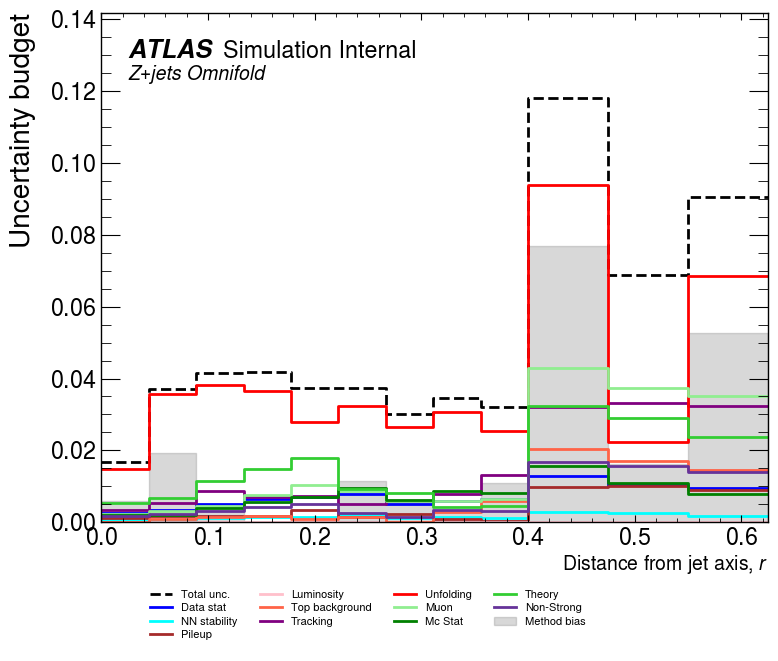

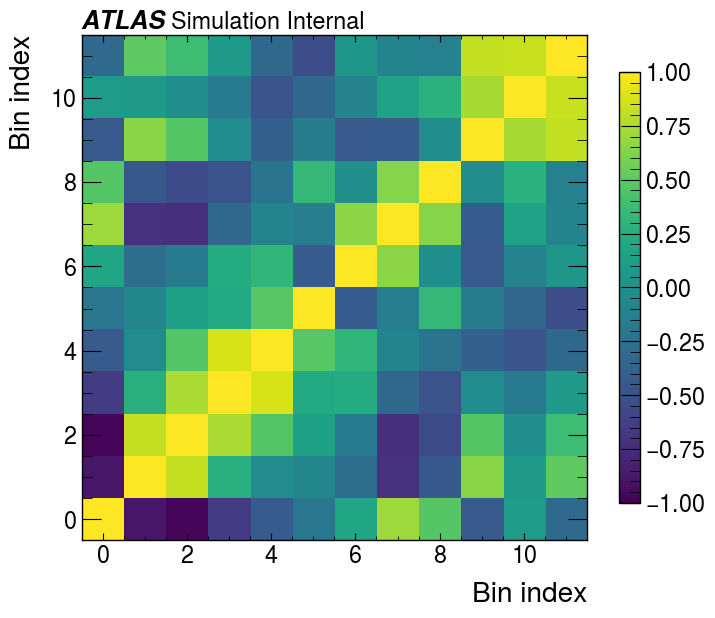

In [12]:
r_edges  = np.concatenate([np.linspace(0, 0.4, 10),
    [0.475, 0.55, 0.625]])
textbox = {
    "left_align": 0.04,
    "top_align": 0.27,
    "text": "Jet $p_{T} \\in [120,150]~\\text{GeV},~ |y| < 1$\nAll tracks\nInclusive jets\nAnti-$k_t$ R=0.4 jets",
    "fontsize": 12
}
formating_PD = {
    "is_madgraph": False,
    "is_omni_data": False,
    "is_truth_pd": True,
    "color": "red",
    "marker": "D",
    "label": "Target",
}

pdf_name = "plots/pd/radial_profile_rho.pdf"
draw_plot(
    omni_results = radial_prof_omni,
    results_list    = [radial_prof_pd_truth],
    formatting_dicts = [formating_PD],
    binning = r_edges,
    ylabel = labels["radial_profile_rho"],
    xlabel = plot_labels["radial_profile_rho"],
    draw_uncertainty_budget = True,
    is_xSec = False,
    is_omni_data=False,
    ratio_ylim  = [0.65,1.35],
    text_box = textbox,
    pdf_name = pdf_name,
    is_profile = True,
    smooth_hv = False
)  

textbox = {
    "left_align": 0.04,
    "top_align": 0.27,
    "text": "Jet $p_{T} \\in [120,150]~\\text{GeV},~ |y| < 1$\nAll tracks\nInclusive jets\nC/A R=0.4 jets",
    "fontsize": 12
}
pdf_name = "plots/pd/radial_profile_rho_CA.pdf"
draw_plot(
    omni_results = radial_prof_CA,
    results_list    = [radial_prof_CA_pd_truth],
    formatting_dicts = [formating_PD],
    binning = r_edges,
    ylabel = labels["radial_profile_rho"],
    xlabel = plot_labels["radial_profile_rho"],
    draw_uncertainty_budget = True,
    is_xSec = False,
    is_omni_data=False,
    ratio_ylim  = [0.65,1.35],
    text_box = textbox,
    pdf_name = pdf_name,
    is_profile = True,
    smooth_hv = False
)  

textbox = {
    "left_align": 0.04,
    "top_align": 0.27,
    "text": "Jet $p_{T} \\in [120,150]~\\text{GeV},~ |y| < 1$\nAll tracks\nInclusive jets\n$k_t$ R=0.4 jets",
    "fontsize": 12
}
pdf_name = "plots/pd/radial_profile_rho_kt.pdf"
draw_plot(
    omni_results = radial_prof_kt,
    results_list    = [radial_prof_kt_pd_truth],
    formatting_dicts = [formating_PD],
    binning = r_edges,
    ylabel = labels["radial_profile_rho"],
    xlabel = plot_labels["radial_profile_rho"],
    draw_uncertainty_budget = True,
    is_xSec = False,
    is_omni_data=False,
    ratio_ylim  = [0.65,1.35],
    text_box = textbox,
    pdf_name = pdf_name,
    is_profile = True,
    smooth_hv = False
)  

## R = 0.5 Anti-kt Jets

In [17]:
algorithm = fj.antikt_algorithm
R = 0.5
n_jobs = 8
jets_omni_R05, event_jet_indices_omni_R05 = build_jets(
    algorithm=algorithm,
    R=R,
    pt=pt_omni,
    eta=eta_omni,
    phi=phi_omni,
    masses=masses_omni,
    n_jobs=n_jobs,
)

jets_hv_R05, event_jet_indices_hv_R05 = build_jets(
    algorithm = algorithm,
    R      = R,
    pt     = pt_hv,
    eta    = eta_hv,
    phi    = phi_hv,
    masses = masses_hv,
    n_jobs = n_jobs,
)

jets_pd_truth_R05, event_jet_indices_pd_truth_R05 = build_jets(
    algorithm=algorithm,
    R=R,
    pt=pt_pd_truth,
    eta=eta_pd_truth,
    phi=phi_pd_truth,
    masses=masses_pd_truth,
    n_jobs=n_jobs,
)

Preparing 1036809 events for clustering
Processing 1036809 events with 8 jobs


Clustering events:   0%|          | 931/1036809 [00:00<12:58, 1331.34event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

Clustering events: 100%|██████████| 1036809/1036809 [02:11<00:00, 7857.98event/s]


Preparing 1377524 events for clustering
Processing 1377524 events with 8 jobs


Clustering events:   0%|          | 869/1377524 [00:00<13:05, 1753.16event/s]

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
#---------------------------------------------------------------------

Clustering events: 100%|██████████| 1377524/1377524 [03:10<00:00, 7213.32event/s]


In [19]:
save_jets_to_file = False
load_jets_from_file = True
if (not load_jets_from_file) and (save_jets_to_file):
    ak.to_parquet(jets_omni_R05,                  file_path +"output/jets_omni_pd_R05.parquet")
    ak.to_parquet(event_jet_indices_omni_R05,     file_path +"output/event_jet_indices_omni_pd_R05.parquet")
    ak.to_parquet(jets_hv_R05,                  file_path +"output/jets_hv_pd_R05.parquet")
    ak.to_parquet(event_jet_indices_hv_R05,     file_path +"output/event_jet_indices_hv_pd_R05.parquet")    
    ak.to_parquet(jets_pd_truth_R05,                  file_path +"output/jets_pd_truth_R05.parquet")
    ak.to_parquet(event_jet_indices_pd_truth_R05,     file_path +"output/event_jet_indices_pd_truth_R05.parquet")   

if (load_jets_from_file):
    jets_omni_R05                  = ak.from_parquet(file_path +"output/jets_omni_pd_R05.parquet")
    event_jet_indices_omni_R05     = ak.from_parquet(file_path +"output/event_jet_indices_omni_pd_R05.parquet")
    jets_hv_R05                    = ak.from_parquet(file_path +"output/jets_hv_pd_R05.parquet")
    event_jet_indices_hv_R05       = ak.from_parquet(file_path +"output/event_jet_indices_hv_pd_R05.parquet")    
    jets_pd_truth_R05              = ak.from_parquet(file_path +"output/jets_pd_truth_R05.parquet")
    event_jet_indices_pd_truth_R05 = ak.from_parquet(file_path +"output/event_jet_indices_pd_truth_R05.parquet")   

In [25]:
r_edges_05  = np.concatenate([np.linspace(0, 0.5, 10),
    [0.575, 0.65, 0.725]])
radial_prof_05      = jet_radial_profile_parallel(
    jets              = jets_omni_R05,
    event_jet_indices = event_jet_indices_omni_R05,
    track_pt          = pt_omni, track_eta=eta_omni, track_phi=phi_omni, track_mass=masses_omni,
    annulus_edges     = r_edges_05,
    weights_dict      = omni_weights,
    only_associated   = False,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)
radial_prof_hv_05      = jet_radial_profile_parallel(
    jets              = jets_hv_R05,
    event_jet_indices = event_jet_indices_hv_R05,
    track_pt          = pt_omni, track_eta=eta_omni, track_phi=phi_omni, track_mass=masses_omni,
    annulus_edges     = r_edges_05,
    weights_dict      = omni_weights,
    only_associated   = False,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)


for obs, weights in radial_prof_hv_05.items():
    if "nominal" in obs:
        radial_prof_05["hv"] = weights


radial_prof_pd_truth_05  = jet_radial_profile_parallel(
    jets              = jets_pd_truth_R05,
    event_jet_indices = event_jet_indices_pd_truth_R05,
    track_pt          = pt_pd_truth, track_eta=eta_pd_truth, track_phi=phi_pd_truth, track_mass=masses_pd_truth,
    annulus_edges     = r_edges_05,
    weights_dict      = pd_truth_weights,
    only_associated   = False,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)

NameError: name 'jets_omni_R05' is not defined

In [24]:
save_hists = False
if save_hists:
    with open(file_path+"output/radial_profile_pd_R05.pkl", "wb") as f:
        pickle.dump(radial_prof_05, f)
    with open(file_path+"output/radial_profile_pd_truth_05.pkl", "wb") as f:
        pickle.dump(radial_prof_pd_truth_05, f)        
load_files = True
if load_files:
    with open(file_path+"output/radial_profile_pd_truth_05.pkl", "rb") as f:
        radial_prof_pd_truth_05 = pickle.load(f)
    with open(file_path+"output/radial_profile_pd_R05.pkl", "rb") as f:
        radial_prof_05 = pickle.load(f)

Chi-squared test: dof=12, χ²=148.24789, p-value=0.0000


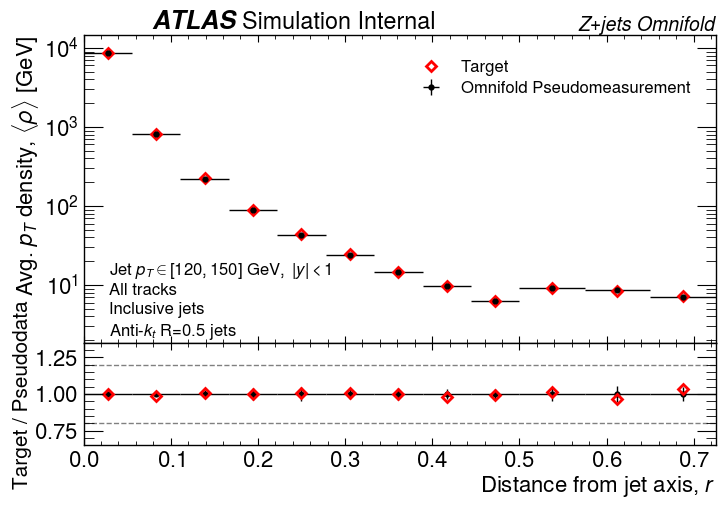

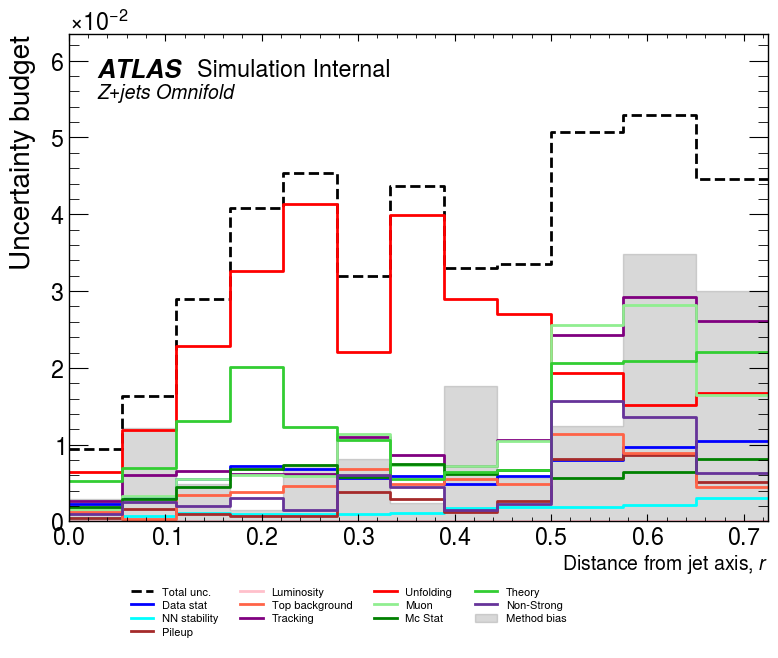

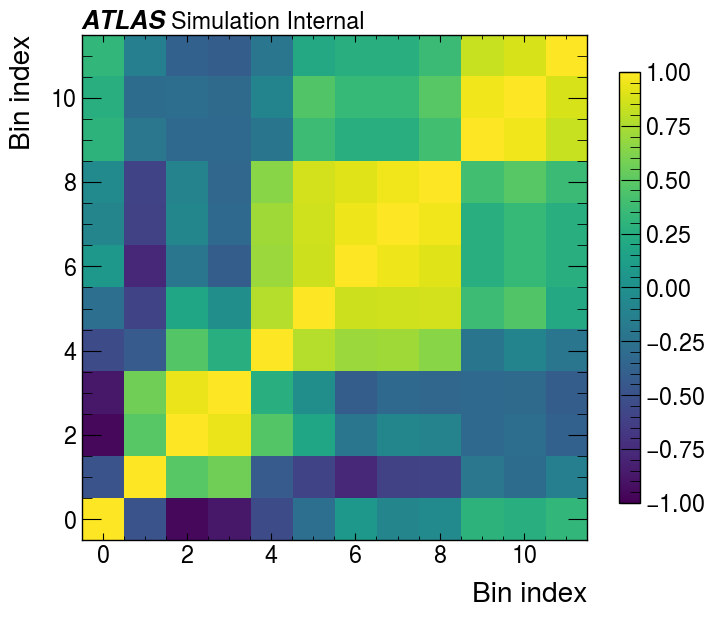

In [27]:
r_edges_05  = np.concatenate([np.linspace(0, 0.5, 10),
    [0.575, 0.65, 0.725]])
textbox = {
    "left_align": 0.04,
    "top_align": 0.27,
    "text": "Jet $p_{T} \\in [120,150]~\\text{GeV},~ |y| < 1$\nAll tracks\nInclusive jets\nAnti-$k_t$ R=0.5 jets",
    "fontsize": 12
}
formating_PD_05 = {
    "is_madgraph": False,
    "is_omni_data": False,
    "is_truth_pd": True,
    "color": "red",
    "marker": "D",
    "label": "Target",
}

pdf_name = "plots/pd/radial_profile_rho_R05.pdf"
draw_plot(
    omni_results = radial_prof_05,
    results_list    = [radial_prof_pd_truth_05],
    formatting_dicts = [formating_PD_05],
    binning = r_edges_05,
    ylabel = labels["radial_profile_rho"],
    xlabel = plot_labels["radial_profile_rho"],
    draw_uncertainty_budget = True,
    is_xSec = False,
    is_omni_data=False,
    ratio_ylim  = [0.65,1.35],
    text_box = textbox,
    pdf_name = pdf_name,
    is_profile = True,
    smooth_hv = False
)    


### Second round of additional plots - Dag wants all 3 ca,kt,anti-kt plotted with only 

In [ ]:
r_edges  = np.concatenate([np.linspace(0, 0.4, 10),
    [0.475, 0.55, 0.625]])
radial_prof_kt_associated      = jet_radial_profile_parallel(
    jets              = jets_omni_kt,
    event_jet_indices = event_jet_indices_omni_kt,
    track_pt          = pt_omni, track_eta=eta_omni, track_phi=phi_omni, track_mass=masses_omni,
    annulus_edges     = r_edges,
    weights_dict      = omni_weights,
    only_associated   = True,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)
print("kt radial profile computed")
radial_prof_CA_associated     = jet_radial_profile_parallel(
    jets              = jets_omni_CA,
    event_jet_indices = event_jet_indices_omni_CA,
    track_pt          = pt_omni, track_eta=eta_omni, track_phi=phi_omni, track_mass=masses_omni,
    annulus_edges     = r_edges,
    weights_dict      = omni_weights,
    only_associated   = True,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)
print("CA radial profile computed")
radial_prof_hv_kt_associated   = jet_radial_profile_parallel(
    jets              = jets_hv_kt,
    event_jet_indices = event_jet_indices_hv_kt,
    track_pt          = pt_hv, track_eta=eta_hv, track_phi=phi_hv, track_mass=masses_hv,
    annulus_edges     = r_edges,
    weights_dict      = hv_weights,
    only_associated   = True,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)
print("HV kt radial profile computed")
radial_prof_hv_CA_associated   = jet_radial_profile_parallel(
    jets              = jets_hv_CA,
    event_jet_indices = event_jet_indices_hv_CA,
    track_pt          = pt_hv, track_eta=eta_hv, track_phi=phi_hv, track_mass=masses_hv,
    annulus_edges     = r_edges,
    weights_dict      = hv_weights,
    only_associated   = False,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = True,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)

radial_prof_omni_associated      = jet_radial_profile_parallel(
    jets              = jets_omni,
    event_jet_indices = event_jet_indices_omni,
    track_pt          = pt_omni, track_eta=eta_omni, track_phi=phi_omni, track_mass=masses_omni,
    annulus_edges     = r_edges,
    weights_dict      = omni_weights,
    only_associated   = True,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)
print("Omni radial profile computed\n")

radial_prof_hv_associated        = jet_radial_profile_parallel(
    jets              = jets_hv,
    event_jet_indices = event_jet_indices_hv,
    track_pt          = pt_hv, track_eta=eta_hv, track_phi=phi_hv, track_mass=masses_hv,
    annulus_edges     = r_edges,
    weights_dict      = hv_weights,
    only_associated   = True,
    jet_pt_range      = np.array([120,150]),
    jet_y_max         = 1,
    use_rho_old       = False,
    compute_psi       = False,
    only_leading_jet  = False,
    max_events        = -1,
    n_jobs            = n_jobs,
)
print("Omni hv radial profile computed\n")


In [ ]:
print("HV CA radial profile computed")
# this just takes the outputs from the hv run, and stores it as a variation on nom in the Omni result, so it can be treated as a syst error later.
for obs, weights in radial_prof_hv_kt_associated.items():
    if "nominal" in obs:
        radial_prof_kt_associated["hv"] = weights
for obs, weights in radial_prof_hv_CA_associated.items():
    if "nominal" in obs:
        radial_prof_CA_associated["hv"] = weights
for obs, weights in radial_prof_hv_associated .items():
    if "nominal" in obs:
        radial_prof_omni_associated["hv"] = weights

In [ ]:
save_hists = True
if save_hists:
    with open(file_path+"output/radial_profile_kt_pd_associated.pkl", "wb") as f:
        pickle.dump(radial_prof_kt_associated, f)
    with open(file_path+"output/radial_profile_CA_pd_associated.pkl", "wb") as f:
        pickle.dump(radial_prof_CA_associated, f)
    with open(file_path+"output/radial_profile_omni_pd_associated.pkl", "wb") as f:
        pickle.dump(radial_prof_omni_associated, f)

In [ ]:

results_list     = [radial_prof_CA_associated, radial_prof_kt_associated, radial_prof_omni_associated]
formatting_dicts = [formating_CA, formating_kt, formating_Anit_kt]

textbox4 = {
    "left_align": 0.04,
    "top_align": 0.27,
    "text": "Jet $p_{T} \\in [120,150]~\\text{GeV},~ |y| < 1$",
    "fontsize": 12
}
pdf_name = "plots/pd/radial_rho_JetAlgos_associated.pdf"
draw_plot(
    omni_results    = radial_prof_CA,
    binning         = r_edges,
    ylabel          = labels["radial_profile_rho"],
    xlabel          = plot_labels["radial_profile_rho"],
    yratiolabel     = "Ratio to C/A",
    draw_uncertainty_budget = True,
    is_xSec         = False,
    ratio_ylim      = [0.65,1.35],
    text_box        = textbox2,
    results_list    = results_list,
    formatting_dicts = formatting_dicts,
    omni_label      = "C/A R=0.4",
    pdf_name        = pdf_name,
    smooth_hv       = False
) 

In [ ]:
if load_hists:
    with open(file_path+"output/radial_profile_kt_pd_truth.pkl", "rb") as f:
        radial_prof_kt_pd_truth = pickle.load(f)
    with open(file_path+"output/radial_profile_CA_pd_truth.pkl", "rb") as f:
        radial_prof_CA_pd_truth = pickle.load(f)

In [ ]:
r_edges  = np.concatenate([np.linspace(0, 0.4, 10),
    [0.475, 0.55, 0.625]])
textbox = {
    "left_align": 0.04,
    "top_align": 0.27,
    "text": "Jet $p_{T} \\in [120,150]~\\text{GeV},~ |y| < 1$\nAll tracks\nInclusive jets\n$k_t$ R=0.4 jets",
    "fontsize": 12
}
formating_PD = {
    "is_madgraph": False,
    "is_omni_data": False,
    "is_truth_pd": True,
    "color": "red",
    "marker": "D",
    "label": "Target",
}

pdf_name = "plots/pd/radial_profile_rho_kt.pdf"
draw_plot(
    omni_results = radial_prof_kt,
    results_list    = [radial_prof_kt_pd_truth],
    formatting_dicts = [formating_PD],
    binning = r_edges,
    ylabel = labels["radial_profile_rho"],
    xlabel = plot_labels["radial_profile_rho"],
    draw_uncertainty_budget = True,
    is_xSec = False,
    is_omni_data=False,
    ratio_ylim  = [0.65,1.35],
    text_box = textbox,
    pdf_name = pdf_name,
    is_profile = True,
    smooth_hv = False
)    

pdf_name = "plots/pd/radial_profile_rho_CA.pdf"
draw_plot(
    omni_results = radial_prof_CA,
    results_list    = [radial_prof_CA_pd_truth],
    formatting_dicts = [formating_PD],
    binning = r_edges,
    ylabel = labels["radial_profile_rho"],
    xlabel = plot_labels["radial_profile_rho"],
    draw_uncertainty_budget = True,
    is_xSec = False,
    is_omni_data=False,
    ratio_ylim  = [0.65,1.35],
    text_box = textbox,
    pdf_name = pdf_name,
    is_profile = True,
    smooth_hv = False
)   

### Calculating and Measuring Jet Observables
for a given list of jets, you may exaluate any simple observable using the 'eval_jet_expressions' function. exp_list can be used to define the observable

#### Usage
Defining Expressions:

- Use **jet tokens**: `<field>_trackj<index>`  
  - `<field>`: `pT`, `y`, `phi`, `m`  
  - `<index>`: 1-based jet number (`trackj1`, `trackj2`, …)  
- Combine with standard **arithmetic operators**: `+`, `-`, `*`, `/`, unary `-`, unary `+`  
- Examples:  
  - `"pT_trackj1 + pT_trackj2"` → sum of first two jets’ pT  
  - `"(pT_trackj1 + pT_trackj2)/2"` → average pT of first two jets  
  - `"y_trackj1 - y_trackj2"` → rapidity difference  

**Rules**:  
- Only valid tokens and operators are allowed.  
- Missing jets automatically produce `-99` in the output.  

Output is a dictionary with keys = expressions and values = array of per event returned values.

Ex: results["pT_trackj1 + pT_trackj9"] -> [80, -99, ...]  (-99 indicates ninth jet is missing in event 2)



In [ ]:
expr_list = [
    "m_trackj1",
    "pT_trackj1",
    "m_trackj1/pT_trackj1 +m_trackj6 * pT_trackj6",

]
start_time = time.time()
jet_obs_omni = eval_jet_expressions(jets_omni, expr_list, nevents=-1)
jet_obs_hv = eval_jet_expressions(jets_hv, expr_list, nevents=-1)
elapsed = time.time() - start_time
print(f"Total runtime: {elapsed:.2f} seconds")

start_time = time.time()
jet_obs_mg_truth = eval_jet_expressions(jets_mg_truth, expr_list, nevents=-1)
start_time = time.time()

start_time = time.time()
jet_obs_sh_truth = eval_jet_expressions(jets_sh_truth, expr_list, nevents=-1)
start_time = time.time()

#### Build histograms for a given observable.
make_hists_with_uncertainty generates nominal, systematic, and replica histograms per observable, returning a structure compatible with `plot_measurement_with_uncertainties`. Enteries in the input "weights_dict" dictstes which uncertainties are calculated.

In [ ]:
omni_hist_results = make_hists_with_uncertainty(
  data         = jet_obs_omni,
  bins         = ibu_bins, 
  observables  = ["m_trackj1", "pT_trackj1"], 
  weights_dict = omni_weights
)
hv_hist_results = make_hists_with_uncertainty(
  data         = jet_obs_hv,
  bins         = ibu_bins, 
  observables  = ["m_trackj1", "pT_trackj1"], 
  weights_dict = hv_weights
)
for obs, weights in hv_hist_results.items():
    if "nominal" in weights:
        omni_hist_results.setdefault(obs, {})["hv"] = weights["nominal"]

mgfxfx_truth_hist_results = make_hists_with_uncertainty(
  data         = jet_obs_mg_truth,
  bins         = ibu_bins, 
  observables  = ["m_trackj1", "pT_trackj1"], 
  weights_dict = mg_truth_weights
)

sherpa_truth_hist_results = make_hists_with_uncertainty(
  data         = jet_obs_sh_truth,
  bins         = ibu_bins, 
  observables  = ["m_trackj1", "pT_trackj1"], 
  weights_dict = sh_truth_weights
)

#### Plotting Results

In [ ]:

draw_plot(
    omni_results = omni_hist_results["m_trackj1"],
    mgfxfx_truth_results = mgfxfx_truth_hist_results["m_trackj1"],
    binning = ibu_bins["m_trackj1"],
    ylabel  = labels["m_trackj1"],
    xlabel  = plot_labels["m_trackj1"],
    draw_uncertainty_budget = True,
    is_xSec = True,
    ratio_ylim = [0.2,1.8],
    dashed_lines_in_ratio = [0.5,1.5],
    is_omni_data = False,
)

### Measuring Total Cross Section vs. Leading Jet Radius

In [ ]:

jet_r = [0.05,0.1,0.2,0.3,0.4]
jets_omni_r_list = []
for r in jet_r:
  jets_omni_r, event_jet_indices_omni_r = build_jets(
      algorithm=algorithm,
      R=r,
      pt=pt_omni,
      eta=eta_omni,
      phi=phi_omni,
      masses=masses_omni,
      n_jobs=n_jobs,
  )
  jets_omni_r_list.append(jets_omni_r)

jets_hv_r_list = []
for r in jet_r:
  jets_hv_r, event_jet_indices_hv_r = build_jets(
      algorithm=algorithm,
      R=r,
      pt=pt_hv,
      eta=eta_hv,
      phi=phi_hv,
      masses=masses_hv,
      n_jobs=n_jobs,
  )
  jets_hv_r_list.append(jets_hv_r)



Now compute the total xsec per jet radius. note, this takes ~1h to run!

In [ ]:
def individual_jet_selection(pt, y, phi, m):
    return (pt > 100) & (abs(y) < 1.2)


jet_r_bins = [0.025, 0.075, 0.125, 0.275, 0.325, 0.475]

jet_count_hist = make_jet_count_histograms(
    jets_list = jets_omni_r_list,
    weights_dict = omni_weights,
    individual_jet_selection = individual_jet_selection,
    bin_edges = jet_r_bins,
    observable_name="xsec",
    leading_jet_only=False,
)

jet_count_hist_hv = make_jet_count_histograms(
    jets_list = jets_hv_r_list,
    weights_dict = hv_weights,
    individual_jet_selection = individual_jet_selection,
    bin_edges = jet_r_bins,
    observable_name="xsec",
    leading_jet_only=False,
)

for obs, weights in jet_count_hist_hv.items():
    if "nominal" in weights:
        jet_count_hist.setdefault(obs, {})["hv"] = weights["nominal"]

#nJets_mg_truth = count_jets(jets_mg_truth, mg_truth_weights["nominal"], individual_jet_selection) 
#nLeadingJets_mg_truth = count_jets(jets_mg_truth, mg_truth_weights["nominal"], individual_jet_selection, leading_jet_only = True)
#print(nJets_mg_truth, nLeadingJets_mg_truth)

In [ ]:

jet_r_bins_dict = {"xsec": np.array(jet_r_bins), "njets": np.array(jet_r_bins)}
draw_plot(
    omni_results = jet_count_hist["xsec"],
    binning = jet_r_bins_dict["xsec"],
    ylabel = 'xSec',
    xlabel = "jet radius",
    draw_uncertainty_budget = True,
    is_xSec = False,
    logyScale = False,
)
